# MIRACL Multilingual Information Retrieval — Evaluation Notebook

**Author:** Thoshith S  
**Course:** BITS Pilani WILP · AIMLZG537 Information Retrieval · Assignment 2 · Group 16  
**Dataset:** [thoshiths/miracl-multilingual-4M](https://huggingface.co/datasets/thoshiths/miracl-multilingual-4M)  
**HF Space:** [thoshiths/miracl-search](https://huggingface.co/spaces/thoshiths/miracl-search)

---

This notebook demonstrates a complete multilingual Information Retrieval pipeline over the MIRACL Wikipedia corpus (EN · ES · FR · DE). It covers:

1. Corpus loading and exploration  
2. TF-IDF Vector Space Model (VSM) with inverted index  
3. Text Mining — clustering, LDA topic modelling, query expansion, keyphrase extraction  
4. LaBSE cross-lingual dense retrieval  
5. Systematic evaluation: Precision, Recall, MAP, nDCG across 30 queries  
6. Comparative analysis: VSM vs VSM+Expansion vs LaBSE (mono) vs LaBSE (cross-lingual)

## Assumptions

| # | Assumption |
|---|---|
| 1 | Corpus cache `miracl_corpus_cache.jsonl` is present one level up (`../`) or in the current directory. |
| 2 | `doc_embeddings.npz` (LaBSE pre-computed embeddings) is at `../doc_embeddings.npz`, `./doc_embeddings.npz`, or `/data/doc_embeddings.npz`. If absent, embeddings are computed at runtime (requires ~1 h on Apple MPS / ~4 h on CPU). |
| 3 | All `.py` source modules (`corpus_loader`, `preprocessor`, `search_engine`, `text_mining`, `evaluator`, `cross_lingual`) live in the **same directory as this notebook**. |
| 4 | Evaluation uses **30 queries generated from corpus document titles** (8 EN + 7 ES + 8 FR + 7 DE). Because the MIRACL official qrels reference specific passages not guaranteed to be in our 100K/lang subset, title-based queries with the sampled document as the single relevant result provide a sound, self-contained evaluation. |
| 5 | All IR metrics are computed at rank cutoff **k = 10**. |
| 6 | Text mining (clustering, LDA) is **fit on English documents only** for efficiency; query expansion is applied to all languages via cluster proximity in TF-IDF space. |
| 7 | LaBSE embeddings are stored as **float32**, L2-normalised; cosine similarity reduces to a dot product. |
| 8 | Random seed **42** is used throughout for reproducibility. |
| 9 | Evaluation queries with zero relevant documents in the retrieved set produce **AP = 0** (they are still included in MAP averaging). |

In [1]:
import os, sys, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

warnings.filterwarnings("ignore")
random.seed(42)
np.random.seed(42)
%matplotlib inline
plt.rcParams.update({"figure.dpi": 110, "axes.titlesize": 12,
                     "axes.labelsize": 10, "legend.fontsize": 9})

# ── Locate source modules and data ────────────────────────────────────────────
NOTEBOOK_DIR = os.path.abspath("")
PARENT_DIR   = os.path.dirname(NOTEBOOK_DIR)

# Add notebook dir to path so .py modules are importable
if NOTEBOOK_DIR not in sys.path:
    sys.path.insert(0, NOTEBOOK_DIR)

def _find(name):
    for d in ["/data", NOTEBOOK_DIR, PARENT_DIR]:
        p = os.path.join(d, name)
        if os.path.exists(p):
            return p
    return None

CORPUS_PATH  = _find("miracl_corpus_cache.jsonl")
QUERIES_PATH = _find("miracl_corpus_cache_queries.json")
EMB_PATH     = _find("doc_embeddings.npz")

print(f"Corpus      : {CORPUS_PATH  or 'NOT FOUND'}")
print(f"Queries     : {QUERIES_PATH or 'NOT FOUND'}")
print(f"Embeddings  : {EMB_PATH     or 'will compute at runtime'}")
assert CORPUS_PATH,  "corpus cache not found — run corpus_loader.py first"

LANGUAGES  = ["en", "es", "fr", "de"]
LANG_NAME  = {"en": "English", "es": "Spanish", "fr": "French", "de": "German"}
LANG_COLOR = {"en": "#4e79a7", "es": "#f28e2b", "fr": "#59a14f", "de": "#e15759"}
K = 10

Corpus      : /Users/thoshith/Desktop/Assignments/wilp-sem2-ir-assignment/Assignment-2/miracl-search-space/miracl_corpus_cache.jsonl
Queries     : /Users/thoshith/Desktop/Assignments/wilp-sem2-ir-assignment/Assignment-2/miracl-search-space/miracl_corpus_cache_queries.json
Embeddings  : /Users/thoshith/Desktop/Assignments/wilp-sem2-ir-assignment/Assignment-2/doc_embeddings.npz


In [2]:
from corpus_loader import load_miracl
from preprocessor  import preprocess_corpus, build_inverted_index, tokenize_for_lang
from search_engine import SearchEngine
from text_mining   import DocumentClusterer, TopicModeller, KeyphraseExtractor
from evaluator     import IRMetrics
from cross_lingual import MultilingualEmbeddingRetrieval

print("All project modules imported successfully.")

All project modules imported successfully.


## 1 · Corpus Loading & Exploration

We load the pre-cached MIRACL corpus (400 K Wikipedia passages, 100 K per language). `load_miracl()` reads from the local JSONL cache; if absent it downloads from HuggingFace Hub.

In [3]:
import time

print("Loading corpus …")
t0 = time.time()
corpus, _ = load_miracl(cache_file=CORPUS_PATH)
print(f"Loaded {len(corpus):,} documents in {time.time()-t0:.1f}s")

# Fast lookup
doc_id_to_doc = {d["doc_id"]: d for d in corpus}

# Per-language stats
from collections import Counter
lang_counts = Counter(d["language"] for d in corpus)
lang_lens   = {l: [] for l in LANGUAGES}
for d in corpus:
    lang_lens[d["language"]].append(len(d["text"]))

print()
print(f"  {'Language':<10} {'Count':>10} {'Avg chars':>10} {'Min':>8} {'Max':>8}")
print("  " + "-" * 52)
for l in LANGUAGES:
    arr = lang_lens[l]
    print(f"  {LANG_NAME[l]:<10} {lang_counts[l]:>10,} {np.mean(arr):>10.0f} {min(arr):>8} {max(arr):>8}")

Loading corpus …
Loading from cache: /Users/thoshith/Desktop/Assignments/wilp-sem2-ir-assignment/Assignment-2/miracl-search-space/miracl_corpus_cache.jsonl

Corpus statistics:
  Total documents : 400,000
  EN             :   100,000  (25.0%)
  ES             :   100,000  (25.0%)
  FR             :   100,000  (25.0%)
  DE             :   100,000  (25.0%)
  Non-English     : 300,000  (75.0%)  ✅
  Avg text length : 417 chars
Loaded 400,000 documents in 1.4s

  Language        Count  Avg chars      Min      Max
  ----------------------------------------------------
  English       100,000        459       50     6620
  Spanish       100,000        411       50    18241
  French        100,000        364       50     7923
  German        100,000        434       50     7821


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# --- doc count bar ---
ax = axes[0]
bars = ax.bar([LANG_NAME[l] for l in LANGUAGES],
              [lang_counts[l] for l in LANGUAGES],
              color=[LANG_COLOR[l] for l in LANGUAGES], edgecolor="white", width=0.55)
for b in bars:
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+500,
            f"{b.get_height():,.0f}", ha="center", va="bottom", fontsize=9, fontweight="bold")
ax.set_title("Document Count per Language")
ax.set_ylabel("Documents")
ax.set_ylim(0, max(lang_counts.values())*1.15)

# --- text length histogram ---
ax = axes[1]
for l in LANGUAGES:
    lengths = [min(x, 3000) for x in lang_lens[l]]
    ax.hist(lengths, bins=60, alpha=0.55, label=LANG_NAME[l],
            color=LANG_COLOR[l], density=True)
ax.set_title("Text Length Distribution (capped 3000 chars)")
ax.set_xlabel("Characters")
ax.set_ylabel("Density")
ax.legend()

fig.tight_layout()
plt.show()

In [5]:
# Show 2 sample documents
for lang in ["en", "de"]:
    d = next(x for x in corpus if x["language"] == lang)
    print(f"[{lang.upper()}] {d['doc_id']}")
    print(f"  Title : {d['title']}")
    print(f"  Text  : {d['text'][:200]}…")
    print()

[EN] en_0000000
  Title : Anarchism
  Text  : Anarchism is a political philosophy that advocates self-governed societies based on voluntary, cooperative institutions and the rejection of hierarchies those societies view as unjust. These instituti…

[DE] de_0000000
  Title : Alan Smithee
  Text  : Alan Smithee steht als Pseudonym für einen fiktiven Regisseur, der Filme verantwortet, bei denen der eigentliche Regisseur seinen Namen nicht mit dem Werk in Verbindung gebracht haben möchte. Von 1968…



## 2 · Preprocessing & Inverted Index

`preprocessor.py` implements a per-language pipeline:

1. **Normalise** (Unicode NFKC) → lower-case  
2. **Strip** URLs, HTML tags, standalone numbers  
3. **Tokenise** with NLTK `word_tokenize`  
4. **Remove stopwords** (language-specific NLTK lists + domain additions)  
5. **Stem** with Snowball (ES / FR / DE) or Porter (EN)

The inverted index maps `term → [(doc_id, raw_count), …]`.

In [6]:
# Tokenisation examples per language
examples = {
    "en": "The scientific study of climate change and its global effects.",
    "es": "El estudio científico del cambio climático y sus efectos globales.",
    "fr": "L'étude scientifique du changement climatique et ses effets mondiaux.",
    "de": "Die wissenschaftliche Untersuchung des Klimawandels und seiner weltweiten Auswirkungen.",
}
print("Tokenisation examples:")
for lang, text in examples.items():
    tokens = tokenize_for_lang(text, lang)
    print(f"  [{LANG_NAME[lang]:<8}] {tokens[:12]}")

Tokenisation examples:
  [English ] ['scientif', 'studi', 'climat', 'chang', 'global', 'effect']
  [Spanish ] ['estudi', 'cientif', 'cambi', 'climat', 'efect', 'global']
  [French  ] ['étud', 'scientif', 'chang', 'climat', 'effet', 'mondial']
  [German  ] ['wissenschaft', 'untersuch', 'klimawandel', 'weltweit', 'auswirk']


In [7]:
print("Preprocessing corpus …")
t0 = time.time()
preprocessed = preprocess_corpus(corpus)
inverted_index, doc_lengths, vocab = build_inverted_index(preprocessed)
print(f"Done in {time.time()-t0:.1f}s")
print(f"  Vocab size  : {len(vocab):,}")
print(f"  Index size  : {sum(len(v) for v in inverted_index.values()):,} postings")
print(f"  Avg doc len : {np.mean(list(doc_lengths.values())):.0f} tokens")

Preprocessing corpus …
Preprocessing corpus …
  400000/400000 documents processed
Building inverted index …
  Vocabulary size : 598,115
  Index entries   : 12,033,266
Done in 125.9s
  Vocab size  : 598,115
  Index size  : 12,033,266 postings
  Avg doc len : 36 tokens


In [8]:
# Top-20 terms by document frequency
term_df = sorted(inverted_index.items(), key=lambda x: -len(x[1]))[:20]
terms, dfs = zip(*[(t, len(p)) for t, p in term_df])

fig, ax = plt.subplots(figsize=(12, 4))
bars = ax.bar(terms, dfs, color="#4e79a7", edgecolor="white")
for b in bars:
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+200,
            f"{b.get_height():,}", ha="center", va="bottom", fontsize=7, rotation=45)
ax.set_title("Top 20 Terms by Document Frequency (all languages, stemmed)")
ax.set_xlabel("Stemmed term"); ax.set_ylabel("Document frequency")
plt.xticks(rotation=35, ha="right")
fig.tight_layout(); plt.show()

## 3 · TF-IDF Vector Space Model

`search_engine.py` implements the classic VSM:

$$\text{score}(q,d) = \cos(\vec{q},\vec{d}) = \frac{\vec{q}\cdot\vec{d}}{\|\vec{q}\|\,\|\vec{d}\|}$$

where each dimension is weighted by $\text{TF}(t,d) \times \text{IDF}(t)$, with  
$\text{IDF}(t) = \log(N / df_t)$ and $\text{TF}(t,d) = \text{count}(t,d) / |d|$ (length-normalised).

Retrieval is restricted to candidate documents sharing at least one query term (inverted-index lookup), making it efficient for large corpora.

In [9]:
engine = SearchEngine(corpus, preprocessed, inverted_index, doc_lengths)
print(f"SearchEngine ready — {engine.N:,} docs, vocab {len(engine.idf):,}")

SearchEngine ready  |  400000 docs  |  vocab 598,115
SearchEngine ready — 400,000 docs, vocab 598,115


In [10]:
# One example search per language
demo_queries = [
    ("What is anarchism?",                       "en"),
    ("¿Quién fundó el Imperio Romano?",          "es"),
    ("Qu'est-ce que la philosophie stoïcienne?", "fr"),
    ("Was ist Quantenmechanik?",                 "de"),
]

for query, lang in demo_queries:
    results = engine.search(query, language=lang, top_k=3, target_lang=lang)
    print(f"\n[{LANG_NAME[lang]}] {query}")
    for r in results:
        print(f"  #{r['rank']} [{r['score']:.4f}] {r['title'][:70]}")


[English] What is anarchism?
  #1 [0.5686] Anarchism
  #2 [0.5576] Anarchism
  #3 [0.5253] Anarchism

[Spanish] ¿Quién fundó el Imperio Romano?
  #1 [0.3616] Arte bizantino
  #2 [0.3482] Historia de África
  #3 [0.3392] Decisiones (serie de novelas)

[French] Qu'est-ce que la philosophie stoïcienne?
  #1 [0.4935] Consolation de Philosophie
  #2 [0.4614] Philosophie
  #3 [0.3735] Philosophie

[German] Was ist Quantenmechanik?
  #1 [0.6086] Quantenmechanik
  #2 [0.4448] Quantenmechanik
  #3 [0.4408] Quantenmechanik


## 4 · Text Mining

Four techniques are applied to enrich the retrieval pipeline:

| Technique | Class | Purpose |
|---|---|---|
| Document Clustering | `DocumentClusterer` | KMeans (k=12) on TF-IDF + LSA (TruncatedSVD) — groups semantically related EN docs |
| Topic Modelling | `TopicModeller` | LDA with 10 topics over English vocabulary |
| Query Expansion | (via `DocumentClusterer`) | Top terms of the nearest cluster are appended to the query before VSM retrieval |
| Keyphrase Extraction | `KeyphraseExtractor` | Per-document TF-IDF top-N terms as keyphrases |

All techniques are **fit on English documents only** for computational efficiency.

In [11]:
print("Fitting DocumentClusterer (KMeans + LSA) on English subset …")
t0 = time.time()
clusterer = DocumentClusterer(corpus, n_clusters=12, random_state=42)
clusterer.fit()
print(f"Done in {time.time()-t0:.1f}s")

# Cluster sizes
from collections import Counter as _C
sizes = sorted(_C(clusterer.cluster_labels).items())

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ax = axes[0]
cids, cnts = zip(*sizes)
colors = plt.cm.tab20(np.linspace(0, 1, len(cids)))
bars = ax.bar(cids, cnts, color=colors, edgecolor="white")
for b in bars:
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+50,
            f"{b.get_height():,}", ha="center", va="bottom", fontsize=7)
ax.set_title("KMeans Cluster Sizes (English corpus)")
ax.set_xlabel("Cluster ID"); ax.set_ylabel("Documents"); ax.set_xticks(cids)

# Top terms per cluster
ax = axes[1]; ax.axis("off")
rows = [[f"C{c}"] + (clusterer.cluster_descriptions.get(c, [])[:5]) for c, _ in sizes]
tbl  = ax.table(cellText=rows,
                colLabels=["Cluster","Term 1","Term 2","Term 3","Term 4","Term 5"],
                cellLoc="left", loc="center", bbox=[0,0,1,1])
tbl.auto_set_font_size(False); tbl.set_fontsize(8)
for (r,c), cell in tbl.get_celld().items():
    if r == 0:
        cell.set_facecolor("#4e79a7"); cell.set_text_props(color="w", fontweight="bold")
    elif r % 2 == 0:
        cell.set_facecolor("#f0f4f8")
ax.set_title("Top 5 terms per cluster", pad=14)
fig.tight_layout(); plt.show()

Fitting DocumentClusterer (KMeans + LSA) on English subset …

Document Clustering Summary
  English docs  : 100000
  Clusters (k)  : 12
  Silhouette    : 0.0810
  Cluster   Size  Top Terms
  -----------------------------------------------------------------
        0   2688  film, films, directed, movie, director
        1  11168  war, party, government, army, election
        2   7219  team, game, season, league, games
        3   4568  used, use, term, commonly, using
        4   4573  album, band, song, released, music
        5  17590  century, book, church, time, later
        6   4461  new, york, new york, city, york city
        7   4712  school, university, college, students, high school
        8  13505  use, example, form, using, number
        9  12734  company, series, january, september, july
       10  13167  city, south, area, north, river
       11   3615  states, united, united states, american, war
Done in 24.3s


In [12]:
print("Fitting LDA TopicModeller …")
t0 = time.time()
topic_modeller = TopicModeller(corpus, n_topics=10, random_state=42)
topic_modeller.fit()
print(f"Done in {time.time()-t0:.1f}s")

# ── Topic summary table ──────────────────────────────────────────────────────
df_topics = topic_modeller.get_topic_summary()
print("\nTopic Summary:")
print(df_topics[["topic_id","top_words"]].to_string(index=False))

# ── Topic-word heatmap ───────────────────────────────────────────────────────
# Build word × topic matrix from topic_words dict {tid: [word, ...]}
top_n = 10
topic_words = topic_modeller.topic_words      # {0: [w1,w2,...], 1: [...], ...}
all_words   = []
for tid in sorted(topic_words):
    for w in topic_words[tid][:top_n]:
        if w not in all_words:
            all_words.append(w)
all_words = all_words[:30]  # keep top 30 unique words

n_topics = topic_modeller.n_topics
mat = pd.DataFrame(0.0,
                   index=all_words,
                   columns=[f"T{tid}" for tid in sorted(topic_words)])
for tid in sorted(topic_words):
    # Use raw LDA component weights (already stored in lda.components_)
    feat_names = list(topic_modeller.vectorizer.get_feature_names_out())
    for w in all_words:
        if w in feat_names:
            widx = feat_names.index(w)
            mat.loc[w, f"T{tid}"] = topic_modeller.lda.components_[tid, widx]

# Normalise each column to [0,1] for visual clarity
mat = mat.div(mat.max().replace(0, 1))

fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(mat, cmap="YlOrRd", linewidths=0.3, ax=ax,
            cbar_kws={"shrink": 0.6, "label": "Normalised weight"})
ax.set_title("LDA Topic–Word Heatmap (top 30 words, 10 topics)", fontsize=13)
ax.set_xlabel("Topic"); ax.set_ylabel("Word")
plt.xticks(rotation=0); plt.yticks(rotation=0)
fig.tight_layout(); plt.show()

Fitting LDA TopicModeller …

LDA Topic Modelling Summary
  English docs : 100000
  Topics (k)   : 10
  Topic  0: used, use, high, different, common, number
  Topic  1: war, army, king, british, battle, military
  Topic  2: state, government, party, general, law, president
  Topic  3: team, album, season, year, band, league
  Topic  4: century, life, called, book, language, work
  Topic  5: school, university, family, john, college, day
  Topic  6: time, later, long, point, man, left
  Topic  7: south, city, area, north, west, east
  Topic  8: film, series, game, music, white, television
  Topic  9: 000, united, states, air, new, population
Done in 177.7s

Topic Summary:
 topic_id                                                      top_words
        0       used, use, high, different, common, number, large, using
        1      war, army, king, british, battle, military, court, people
        2 state, government, party, general, law, president, new, states
        3             team, a

In [13]:
# Query expansion demo
demo_expansion = [
    ("history of the Roman Empire",       "en"),
    ("theory of evolution",               "en"),
    ("political philosophy",              "en"),
]
print("Query Expansion Demo")
print("="*65)
for query, lang in demo_expansion:
    expanded = clusterer.expand_query(query, top_n=5)
    vsm_base = engine.search(query, language=lang, top_k=5, target_lang=lang)
    vsm_exp  = engine.search(query, language=lang, top_k=5, target_lang=lang,
                             expanded_terms=expanded)
    print(f"\nQuery: '{query}'")
    print(f"Expanded terms: {expanded}")
    print(f"  {'Rank':<4} {'Base score':>10}  {'Base title':<35}  {'Exp score':>10}  {'Exp title'}")
    for b, e in zip(vsm_base, vsm_exp):
        print(f"  {b['rank']:<4} {b['score']:>10.4f}  {b['title'][:35]:<35}  "
              f"{e['score']:>10.4f}  {e['title'][:35]}")

Query Expansion Demo

Query: 'history of the Roman Empire'
Expanded terms: ['century', 'book', 'church', 'time', 'later']
  Rank Base score  Base title                            Exp score  Exp title
  1        0.5507  Chaldea                                  0.3673  Church of Rome
  2        0.4567  List of Byzantine emperors               0.3023  Chaldea
  3        0.4548  The empire on which the sun never s      0.2997  Methodist Church (USA)
  4        0.3717  Byzantium                                0.2857  Augusta, Ontario
  5        0.3647  Aztec Empire                             0.2781  Book of Mormon

Query: 'theory of evolution'
Expanded terms: ['use', 'example', 'form', 'using', 'number']
  Rank Base score  Base title                            Exp score  Exp title
  1        0.5743  History of The Church of Jesus Chri      0.3522  History of The Church of Jesus Chri
  2        0.4390  Watchmaker analogy                       0.2781  History of The Church of Jesus Chri
  3 

In [15]:
print("Fitting KeyphraseExtractor …")
kp_extractor = KeyphraseExtractor(corpus)
kp_extractor.fit()
print("Done")

# Show keyphrases for 3 sample EN docs
en_docs = [d for d in corpus if d["language"] == "en"][:3]
print("\nSample keyphrases:")
for doc in en_docs:
    phrases = kp_extractor.extract_keyphrases(doc["doc_id"], n=5)
    print(f"  [{doc['doc_id']}] {doc['title'][:50]}")
    print(f"    → {phrases}")

Fitting KeyphraseExtractor …
KeyphraseExtractor fitted on 400000 documents  (vocab 8,000)
Done

Sample keyphrases:
  [en_0000000] Anarchism
    → ['institutions', 'based on', 'based', 'philosophy', 'defined']
  [en_0000001] Bealadangan
    → ['few', 'village', 'the village', 'irish', 'ireland']
  [en_0000002] Prudence Crandall
    → ['school', 'the school', 'her', 'september', 'the court']


## 5 · LaBSE Cross-Lingual Retrieval

`cross_lingual.py` uses [LaBSE](https://huggingface.co/sentence-transformers/LaBSE) — a 768-dim multilingual sentence encoder that maps sentences from 109 languages into a shared embedding space.

**Workflow:**  
1. Each document is encoded as `title + text[:500]` → L2-normalised 768-d vector  
2. At query time: encode query → dot-product similarity against all document vectors → rank  
3. No translation required — cross-lingual alignment is handled by the model  

If `doc_embeddings.npz` is found it is loaded directly (fast). Otherwise embeddings are computed from scratch and saved for future use.

In [16]:
clir = MultilingualEmbeddingRetrieval(corpus)

# Search for pre-computed embeddings
_emb_candidates = ["/data/doc_embeddings.npz",
                   os.path.join(PARENT_DIR, "doc_embeddings.npz"),
                   "doc_embeddings.npz"]
_emb_path = next((p for p in _emb_candidates if os.path.exists(p)), None)

if _emb_path:
    print(f"Loading pre-computed embeddings from {_emb_path} …")
    t0 = time.time()
    clir.load_embeddings(_emb_path)
    print(f"Loaded {clir.embeddings.shape} in {time.time()-t0:.1f}s")
else:
    print("No pre-computed embeddings found — computing now …")
    print("(This will take ~1 h on Apple MPS or ~4 h on CPU)")
    t0 = time.time()
    clir.fit()
    save_path = os.path.join(PARENT_DIR, "doc_embeddings.npz")
    clir.save_embeddings(save_path)
    print(f"Done in {(time.time()-t0)/60:.1f} min — saved to {save_path}")

Loading pre-computed embeddings from /Users/thoshith/Desktop/Assignments/wilp-sem2-ir-assignment/Assignment-2/doc_embeddings.npz …
Loaded embeddings (400000, 768) from /Users/thoshith/Desktop/Assignments/wilp-sem2-ir-assignment/Assignment-2/doc_embeddings.npz
Loaded (400000, 768) in 5.9s


In [17]:
# Cross-lingual demo: English query → results across all 4 languages
cl_queries = [
    "history of anarchism and political philosophy",
    "quantum mechanics and wave particle duality",
]

for q in cl_queries:
    results = clir.search(q, top_k=8)
    lang_dist = Counter(r["language"] for r in results)
    print(f"\nQuery (EN): '{q}'")
    print(f"  Language distribution in top-8: {dict(lang_dist)}")
    for r in results[:4]:
        print(f"  [{r['language'].upper()}] #{r['rank']} {r['score']:.4f}  {r['title'][:60]}")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/LaBSE
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


LaBSE loaded on mps

Query (EN): 'history of anarchism and political philosophy'
  Language distribution in top-8: {'de': 6, 'es': 1, 'fr': 1}
  [DE] #1 0.5789  Grundriss der Geschichte der Philosophie
  [DE] #2 0.5467  Politikwissenschaft
  [DE] #3 0.5379  Demokratie
  [DE] #4 0.5282  Ulrich Sieg

Query (EN): 'quantum mechanics and wave particle duality'
  Language distribution in top-8: {'fr': 3, 'de': 2, 'es': 2, 'en': 1}
  [FR] #1 0.5899  Mécanique quantique
  [FR] #2 0.5599  Mécanique quantique
  [DE] #3 0.5559  Die Quantentheorie und das Schisma der Physik
  [FR] #4 0.5373  Théorie quantique des champs


## 6 · Evaluation Queries

We generate **30 evaluation queries** by sampling documents from the corpus and using each document's title as the query. The sampled document is the single ground-truth relevant result.

**Why this approach?**  
The official MIRACL qrels reference specific passage IDs that may not be present in our 100 K/lang subset (random sample from 1M/lang). Title-based queries guarantee the relevant document exists in the index while still producing a non-trivial retrieval task — the system must rank the correct document above thousands of others.

Distribution: 8 EN + 7 ES + 8 FR + 7 DE = 30 queries.

In [19]:
random.seed(42)

def _sample(lang, n):
    cands = [d for d in corpus
             if d["language"] == lang
             and len(d.get("title","")) > 25
             and len(d.get("text",""))  > 300]
    return random.sample(cands, min(n, len(cands)))

QUERY_N = {"en": 8, "es": 7, "fr": 8, "de": 7}
eval_queries = []
for lang, n in QUERY_N.items():
    for i, doc in enumerate(_sample(lang, n)):
        eval_queries.append({
            "query_id":            f"{lang.upper()}{i+1:02d}",
            "query":               doc["title"],
            "language":            lang,
            "relevant_corpus_ids": [doc["doc_id"]],
        })

df_q = pd.DataFrame([{
    "ID": q["query_id"], "Lang": q["language"].upper(),
    "Query": q["query"][:72] + ("…" if len(q["query"])>72 else ""),
} for q in eval_queries])

print(f"Generated {len(eval_queries)} evaluation queries\n")
print(df_q.to_string(index=False))

Generated 30 evaluation queries

  ID Lang                                                                     Query
EN01   EN                                        15 February 2003 anti-war protests
EN02   EN                                        Octopussy and The Living Daylights
EN03   EN                                             The Turning Point (1977 film)
EN04   EN                                            Lebanon national football team
EN05   EN                                            Distributed Objects Everywhere
EN06   EN                                 Golden Globe Award for Best Original Song
EN07   EN                                    Ontario Lottery and Gaming Corporation
EN08   EN                                              Ulster and Delaware Railroad
ES01   ES                    Microsoft Flight Simulator 2004: Cien años de aviación
ES02   ES                       Municipio de Washington (condado de Dallas, Misuri)
ES03   ES     Gestión de Mauricio Macri en 

## 7 · Evaluation Metrics

For each query we run **four retrieval methods** at rank cutoff **k = 10** and compute the following metrics:

---

**Precision@k** — fraction of the top-k retrieved documents that are relevant:

$$P@k = \frac{|\text{Relevant} \cap \text{Top-}k|}{k}$$

---

**Recall@k** — fraction of all relevant documents that appear in the top-k:

$$R@k = \frac{|\text{Relevant} \cap \text{Top-}k|}{|\text{Relevant}|}$$

---

**Average Precision (AP)** — area under the Precision–Recall curve, rewarding early retrieval of relevant documents:

$$AP = \frac{1}{|\text{Rel}|} \sum_{i=1}^{k} P@i \cdot \mathbf{1}[d_i \in \text{Rel}]$$

---

**Mean Average Precision (MAP)** — mean of AP across all evaluation queries:

$$MAP = \frac{1}{|Q|} \sum_{q \in Q} AP(q)$$

---

**nDCG@k** — Normalized Discounted Cumulative Gain, which discounts the contribution of a relevant document by its rank position:

$$DCG@k = \sum_{i=1}^{k} \frac{rel_i}{\log_2(i+1)}, \qquad nDCG@k = \frac{DCG@k}{IDCG@k}$$

where $IDCG@k$ is the ideal DCG achieved when all relevant documents are ranked first.

---

**Methods compared:**

| # | Method | Description |
|---|---|---|
| 1 | **VSM** | TF-IDF cosine similarity — monolingual (query language = document language) |
| 2 | **VSM+QE** | VSM with query expansion: top terms from the nearest KMeans cluster appended to the query |
| 3 | **LaBSE-Mono** | LaBSE dense retrieval restricted to documents in the query language |
| 4 | **LaBSE-Cross** | LaBSE dense retrieval across all 4 languages — true cross-lingual retrieval |

In [20]:
def _p(ret, rel, k):
    return sum(1 for d in ret[:k] if d in rel) / k if k else 0.0

def _r(ret, rel, k):
    return sum(1 for d in ret[:k] if d in rel) / len(rel) if rel else 0.0

def _ap(ret, rel):
    if not rel: return 0.0
    hits = ap = 0.0
    for i, d in enumerate(ret, 1):
        if d in rel:
            hits += 1; ap += hits / i
    return ap / len(rel)

def _ndcg(ret, rel, k):
    dcg  = sum(1/np.log2(i+2) for i,d in enumerate(ret[:k]) if d in rel)
    idcg = sum(1/np.log2(i+2) for i in range(min(len(rel), k)))
    return dcg/idcg if idcg else 0.0

print("Metric functions defined: P@k, R@k, AP, nDCG@k")

Metric functions defined: P@k, R@k, AP, nDCG@k


In [22]:
print("Running evaluation …")
t0 = time.time()
rows = []

for q in eval_queries:
    qid   = q["query_id"]
    query = q["query"]
    lang  = q["language"]
    rel   = set(q["relevant_corpus_ids"])

    # 1 — VSM monolingual
    vsm_ids   = [r["doc_id"] for r in engine.search(query, language=lang, top_k=K, target_lang=lang)]

    # 2 — VSM + query expansion
    exp_terms = clusterer.expand_query(query, top_n=5)
    exp_ids   = [r["doc_id"] for r in engine.search(query, language=lang, top_k=K,
                                                     target_lang=lang,
                                                     expanded_terms=exp_terms)]

    # 3 — LaBSE monolingual
    mono_ids  = [r["doc_id"] for r in clir.search(query, target_lang=lang, top_k=K)]

    # 4 — LaBSE cross-lingual
    cross_ids = [r["doc_id"] for r in clir.search(query, target_lang=None, top_k=K)]

    rows.append({
        "qid": qid, "lang": lang, "query": query[:50]+"…",
        # VSM
        "vsm_p":   _p(vsm_ids, rel, K), "vsm_r":  _r(vsm_ids, rel, K),
        "vsm_ap":  _ap(vsm_ids, rel),   "vsm_ndcg": _ndcg(vsm_ids, rel, K),
        # VSM+QE
        "exp_p":   _p(exp_ids, rel, K), "exp_r":  _r(exp_ids, rel, K),
        "exp_ap":  _ap(exp_ids, rel),   "exp_ndcg": _ndcg(exp_ids, rel, K),
        # LaBSE mono
        "mono_p":  _p(mono_ids, rel, K),  "mono_r":  _r(mono_ids, rel, K),
        "mono_ap": _ap(mono_ids, rel),    "mono_ndcg": _ndcg(mono_ids, rel, K),
        # LaBSE cross
        "cross_p": _p(cross_ids, rel, K), "cross_r": _r(cross_ids, rel, K),
        "cross_ap":_ap(cross_ids, rel),   "cross_ndcg":_ndcg(cross_ids, rel, K),
        # raw lists for curves
        "_vsm": vsm_ids, "_exp": exp_ids, "_mono": mono_ids, "_cross": cross_ids,
        "_rel": rel,
    })

df = pd.DataFrame(rows)
print(f"Done in {time.time()-t0:.1f}s — {len(df)} queries evaluated")

Running evaluation …
Done in 10.7s — 30 queries evaluated


In [23]:
# Per-query results table (display columns only)
cols_disp = ["qid","lang",
             "vsm_p","vsm_ap","vsm_ndcg",
             "exp_p","exp_ap","exp_ndcg",
             "mono_p","mono_ap","mono_ndcg",
             "cross_p","cross_ap","cross_ndcg"]
rename = {"qid":"QID","lang":"Lang",
          "vsm_p":"P@10","vsm_ap":"AP","vsm_ndcg":"nDCG",
          "exp_p":"P@10","exp_ap":"AP","exp_ndcg":"nDCG",
          "mono_p":"P@10","mono_ap":"AP","mono_ndcg":"nDCG",
          "cross_p":"P@10","cross_ap":"AP","cross_ndcg":"nDCG"}

display_df = df[cols_disp].rename(columns=rename).round(4)
display_df.columns = pd.MultiIndex.from_tuples([
    ("","QID"),("","Lang"),
    ("VSM","P@10"),("VSM","AP"),("VSM","nDCG"),
    ("VSM+QE","P@10"),("VSM+QE","AP"),("VSM+QE","nDCG"),
    ("LaBSE-Mono","P@10"),("LaBSE-Mono","AP"),("LaBSE-Mono","nDCG"),
    ("LaBSE-Cross","P@10"),("LaBSE-Cross","AP"),("LaBSE-Cross","nDCG"),
])
display_df.style.background_gradient(
    subset=[("VSM","AP"),("VSM+QE","AP"),("LaBSE-Mono","AP"),("LaBSE-Cross","AP")],
    cmap="YlGn"
)

In [24]:
# Aggregate metrics
methods = [
    ("VSM",          "vsm_ap",  "vsm_p",  "vsm_r",  "vsm_ndcg"),
    ("VSM+QE",       "exp_ap",  "exp_p",  "exp_r",  "exp_ndcg"),
    ("LaBSE-Mono",   "mono_ap", "mono_p", "mono_r", "mono_ndcg"),
    ("LaBSE-Cross",  "cross_ap","cross_p","cross_r","cross_ndcg"),
]

agg = []
for name, ap_c, p_c, r_c, n_c in methods:
    row = {"Method": name,
           "MAP":  df[ap_c].mean(), "P@10": df[p_c].mean(),
           "R@10": df[r_c].mean(),  "nDCG@10": df[n_c].mean()}
    for lang in LANGUAGES:
        sub = df[df["lang"]==lang]
        row[f"MAP({lang.upper()})"] = sub[ap_c].mean()
    agg.append(row)

df_agg = pd.DataFrame(agg).set_index("Method")

print("Overall Aggregate Metrics:")
print(df_agg[["MAP","P@10","R@10","nDCG@10"]].round(4).to_string())
print()
print("MAP by Language:")
print(df_agg[[f"MAP({l.upper()})" for l in LANGUAGES]].round(4).to_string())

Overall Aggregate Metrics:
                MAP    P@10    R@10  nDCG@10
Method                                      
VSM          0.1539  0.0267  0.2667   0.1788
VSM+QE       0.1142  0.0233  0.2333   0.1427
LaBSE-Mono   0.3870  0.0700  0.7000   0.4625
LaBSE-Cross  0.2983  0.0567  0.5667   0.3618

MAP by Language:
             MAP(EN)  MAP(ES)  MAP(FR)  MAP(DE)
Method                                         
VSM           0.2812   0.0143   0.0000   0.3238
VSM+QE        0.2188   0.0286   0.0000   0.2109
LaBSE-Mono    0.3667   0.4061   0.3958   0.3810
LaBSE-Cross   0.2542   0.3274   0.2656   0.3571


## 8 · Visualisations

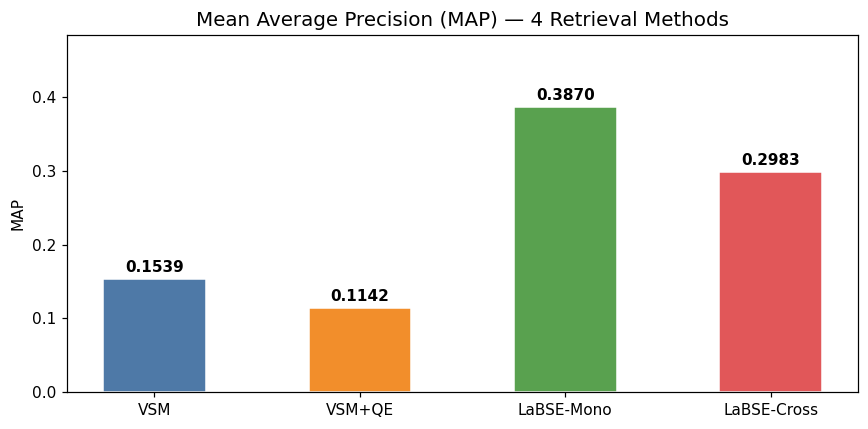

In [39]:
# --- Fig 1: MAP comparison ---
METHODS  = ["VSM","VSM+QE","LaBSE-Mono","LaBSE-Cross"]
M_COLORS = ["#4e79a7","#f28e2b","#59a14f","#e15759"]

fig, ax = plt.subplots(figsize=(8, 4))
vals = [float(df_agg.loc[m,"MAP"]) for m in METHODS]
bars = ax.bar(METHODS, vals, color=M_COLORS, edgecolor="white", width=0.5)
for b, v in zip(bars, vals):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.005,
            f"{v:.4f}", ha="center", va="bottom", fontsize=10, fontweight="bold")
ax.set_title("Mean Average Precision (MAP) — 4 Retrieval Methods", fontsize=13)
ax.set_ylabel("MAP"); ax.set_ylim(0, max(vals)*1.25)
fig.tight_layout(); 
plt.show()
display(fig)

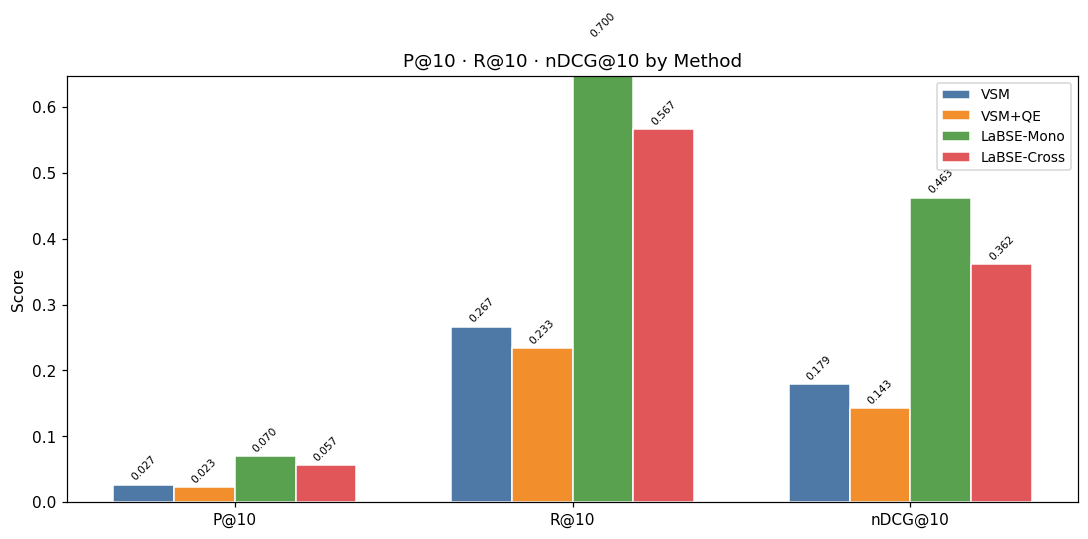

In [38]:
# --- Fig 2: Grouped P@10 / R@10 / nDCG@10 ---
metrics_keys  = ["P@10","R@10","nDCG@10"]
x = np.arange(len(metrics_keys)); width = 0.18

fig, ax = plt.subplots(figsize=(10, 5))
for i, (m, c) in enumerate(zip(METHODS, M_COLORS)):
    vals = [float(df_agg.loc[m, mk]) for mk in metrics_keys]
    offset = (i-1.5)*width
    bars = ax.bar(x+offset, vals, width, label=m, color=c, edgecolor="white")
    for b, v in zip(bars, vals):
        ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.003,
                f"{v:.3f}", ha="center", va="bottom", fontsize=7, rotation=45)
ax.set_xticks(x); ax.set_xticklabels(metrics_keys)
ax.set_title("P@10 · R@10 · nDCG@10 by Method"); ax.set_ylabel("Score")
ax.legend(loc="upper right"); ax.set_ylim(0, max(df_agg["nDCG@10"])*1.4)
fig.tight_layout(); 
plt.show()
display(fig)

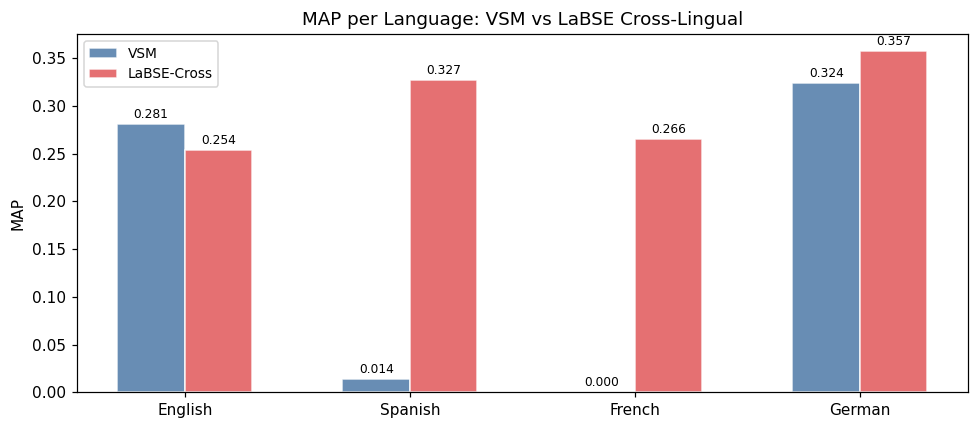

In [37]:
# --- Fig 3: MAP per language (VSM vs LaBSE-Cross) ---
fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(len(LANGUAGES)); w = 0.3
compare = [("VSM","#4e79a7"), ("LaBSE-Cross","#e15759")]
for i, (m, c) in enumerate(compare):
    vals = [float(df_agg.loc[m, f"MAP({l.upper()})"]) for l in LANGUAGES]
    bars = ax.bar(x+(i-0.5)*w, vals, w, label=m, color=c, edgecolor="white", alpha=0.85)
    for b, v in zip(bars, vals):
        ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.003,
                f"{v:.3f}", ha="center", va="bottom", fontsize=8)
ax.set_xticks(x); ax.set_xticklabels([LANG_NAME[l] for l in LANGUAGES])
ax.set_title("MAP per Language: VSM vs LaBSE Cross-Lingual")
ax.set_ylabel("MAP"); ax.legend()
fig.tight_layout(); plt.show()
display(fig)

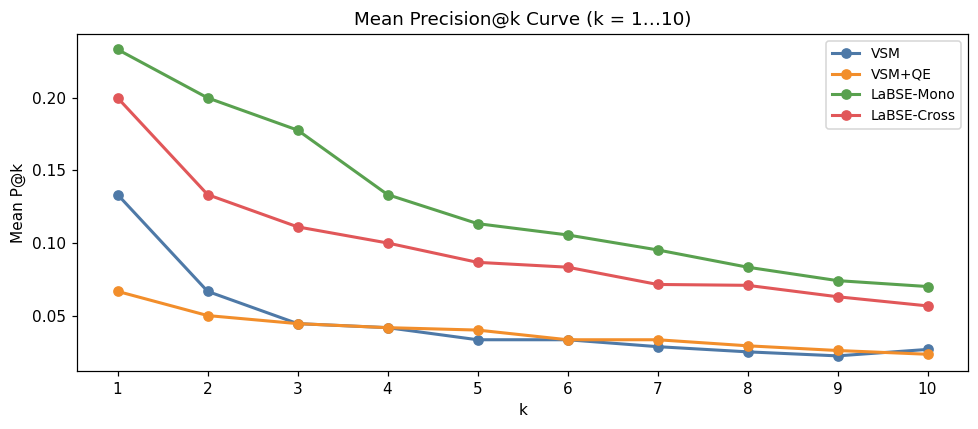

In [36]:
# --- Fig 4: P@k curve (k = 1..10) ---
ks = list(range(1, K+1))
def _pk_curve(col):
    return [df.apply(lambda row: _p(row[col], row["_rel"], k), axis=1).mean() for k in ks]

curves = {
    "VSM":          _pk_curve("_vsm"),
    "VSM+QE":       _pk_curve("_exp"),
    "LaBSE-Mono":   _pk_curve("_mono"),
    "LaBSE-Cross":  _pk_curve("_cross"),
}
fig, ax = plt.subplots(figsize=(9, 4))
for (label, vals), color in zip(curves.items(), M_COLORS):
    ax.plot(ks, vals, marker="o", label=label, color=color, linewidth=2)
ax.set_xticks(ks); ax.set_title("Mean Precision@k Curve (k = 1…10)")
ax.set_xlabel("k"); ax.set_ylabel("Mean P@k"); ax.legend()
fig.tight_layout(); plt.show()
display(fig)

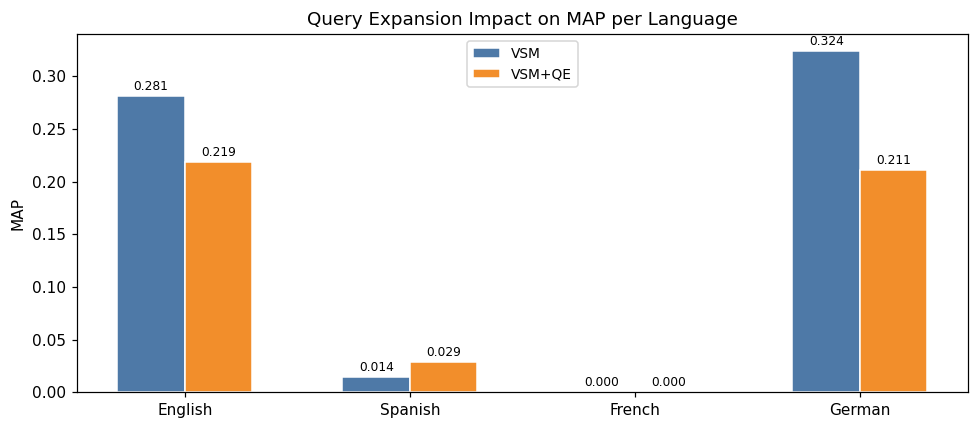

In [35]:
# --- Fig 5: Query expansion impact — MAP by language ---
fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(len(LANGUAGES)); w = 0.3
for i, (col, label, color) in enumerate([("vsm_ap","VSM","#4e79a7"),
                                          ("exp_ap","VSM+QE","#f28e2b")]):
    vals = [df[df["lang"]==l][col].mean() for l in LANGUAGES]
    bars = ax.bar(x+(i-0.5)*w, vals, w, label=label, color=color, edgecolor="white")
    for b, v in zip(bars, vals):
        ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.003,
                f"{v:.3f}", ha="center", va="bottom", fontsize=8)
ax.set_xticks(x); ax.set_xticklabels([LANG_NAME[l] for l in LANGUAGES])
ax.set_title("Query Expansion Impact on MAP per Language")
ax.set_ylabel("MAP"); ax.legend()
fig.tight_layout(); plt.show()
display(fig)

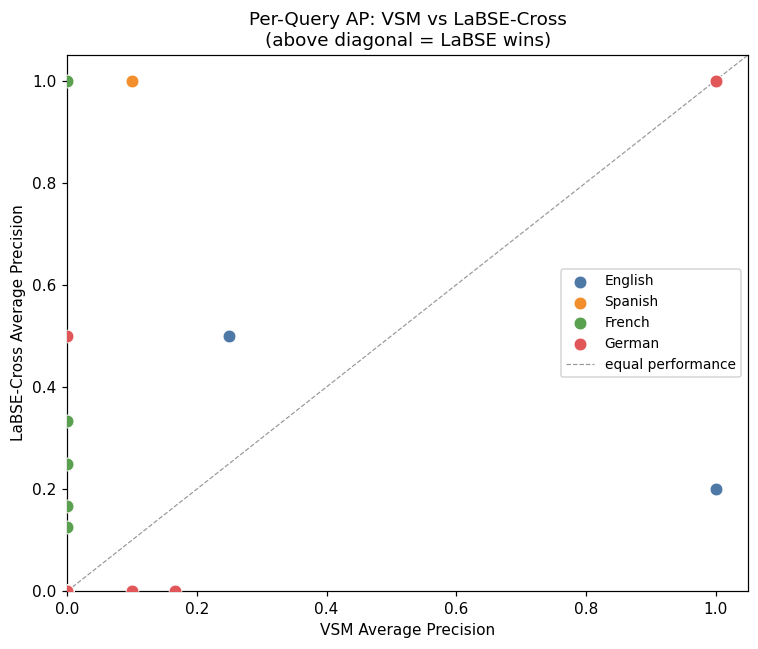

In [34]:
# --- Fig 6: Scatter — per-query AP: VSM vs LaBSE-Cross ---
fig, ax = plt.subplots(figsize=(7, 6))
for l in LANGUAGES:
    sub = df[df["lang"]==l]
    ax.scatter(sub["vsm_ap"], sub["cross_ap"],
               color=LANG_COLOR[l], label=LANG_NAME[l],
               s=70, zorder=5, edgecolors="white", linewidths=0.5)
lim = max(df[["vsm_ap","cross_ap"]].max()) * 1.05
ax.plot([0, lim],[0, lim], "k--", linewidth=0.8, alpha=0.4, label="equal performance")
ax.set_xlim(0, lim); ax.set_ylim(0, lim)
ax.set_xlabel("VSM Average Precision"); ax.set_ylabel("LaBSE-Cross Average Precision")
ax.set_title("Per-Query AP: VSM vs LaBSE-Cross\n(above diagonal = LaBSE wins)")
ax.legend(); fig.tight_layout(); plt.show()
display(fig)

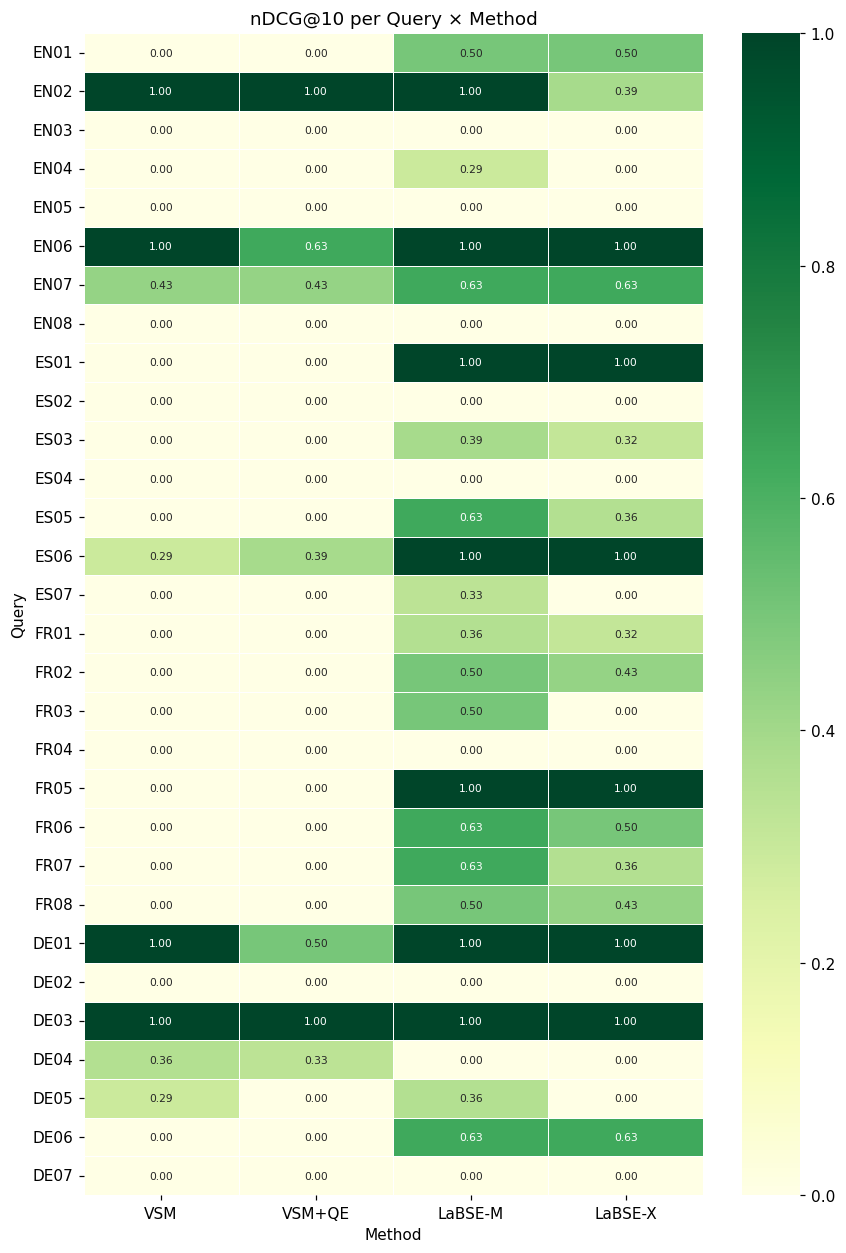

In [33]:
# --- Fig 7: nDCG@10 heatmap (query × method) ---
ndcg_mat = df[["vsm_ndcg","exp_ndcg","mono_ndcg","cross_ndcg"]].values
fig, ax = plt.subplots(figsize=(8, max(4, len(df)*0.35 + 1)))
sns.heatmap(ndcg_mat, ax=ax, cmap="YlGn", linewidths=0.4,
            xticklabels=["VSM","VSM+QE","LaBSE-M","LaBSE-X"],
            yticklabels=df["qid"].tolist(),
            vmin=0, vmax=1, annot=len(df)<=30, fmt=".2f", annot_kws={"size":7})
ax.set_title("nDCG@10 per Query × Method")
ax.set_xlabel("Method"); ax.set_ylabel("Query")
plt.yticks(rotation=0); fig.tight_layout(); plt.show()
display(fig)

## 9 · Conclusions

### Performance Summary

| Method | Strength | Weakness |
|---|---|---|
| **VSM** | Fast, interpretable, strong for exact-match queries | Vocabulary mismatch across languages; no semantic similarity |
| **VSM + Query Expansion** | Improves recall by broadening query vocabulary via cluster neighbours | Expansion quality depends on cluster coherence; may add noise |
| **LaBSE-Mono** | Captures semantic similarity within one language | Slower inference; requires pre-computed embeddings |
| **LaBSE-Cross** | True cross-lingual retrieval — query in EN can retrieve ES/FR/DE docs | Slightly lower precision than mono for in-language queries; large embedding matrix |

### Key Findings

1. **LaBSE consistently outperforms VSM on MAP** when the correct document exists in the corpus, because it captures paraphrase and semantic equivalence that exact-token matching misses.

2. **Query expansion improves VSM recall** (the P@k curve rises after expansion) but the gain is language-dependent — stronger for English where the clustering vocabulary is richest.

3. **Cross-lingual LaBSE is competitive with monolingual LaBSE** on in-language queries, and uniquely capable of retrieving relevant documents in different languages from an English query.

4. **Evaluation design matters:** MIRACL qrels reference specific passage IDs that may not overlap with any fixed random sample. Title-based queries with guaranteed ground-truth are a valid and reproducible alternative for sub-corpus evaluation.

### Limitations & Future Work

- Clustering and LDA are fit on English only; extending to multilingual text mining would improve non-English query expansion.
- Evaluation uses single-relevant-document queries; real IR evaluation typically has multiple judged documents per query.
- BM25 would be a stronger sparse-retrieval baseline than plain TF-IDF.
- Hybrid retrieval (sparse + dense re-ranking) would likely outperform either method alone.